In [ ]:
from google.colab import files
import io

uploaded = files.upload()

Saving patient_lung_sim_results.csv to patient_lung_sim_results.csv


## Clustering PE patient based on the Lung simulated data


Minh Cao

## Goal
- Build an interpretable model to group Pectus Excavatum patients based on lung simulation and demographic data
- Explore whether patients form distinct subtypes or follow a continuous severity pattern


## Steps
#### 1. Understand the data
- Load and check dataset, check data types
- Handle inconsistency
- Normalize/ standardize numerical features
- Encode categorical features
#### 2. Explore data
- Correlation matrix to find relationships among simulated variables
- PCA to viusalize overall structure in low dimension (to see if there are visible groups or continuous spread)
#### 3. Apply interpretable clustering
- Start with Herachical Clustering to visualize how patients group
- Test K-means, DBSCAN, GMM for comparison
#### 4. Evaluate and interpret clusteres
#### 5. Insights

## Data Summary
### Simulated Variable with period of 10 seconds:

##### Lung Volume
- Capacity of the air within the lungs

##### Transpulmonary Pressure Mean
- Average lung stretch force, in PE patient, chest compress the lung -> lungs don't expand as easily -> lower V02 max -> Lower aerobic capacity
##### Alv Pressure Peak
- Alveoli : a tiny tube in the lung that help with gas exchange. When you breath in oxygen, aveoli help transfer the oxygen inside your bloodstream, and transfer co2 from your bloodstream to exhale
- Alv Pressure Peak: The highest pressure reached inside the alveoli during breathing or exercise
- Too low: weak airflow, poor ventilation
- Too high: einefficient breathing, airway resistance


##### Respiratory Flow Peak:
- Fastest speed of air movinig in and out of your lungs.
- Doctor use this to see how well your lungs can push or pull air
- Normal peek:  airways are open and air moves easily
- Low peak: narrowed or restric airways (like asthma or chest compression in PE)


##### Summary
- For PE patient, you tend to have lower compliances(flexibility on the lung and thoraic) and higher resitances, which both contribute to higer effor in breathing

In [ ]:
# Import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

In [ ]:
pe = pd.read_csv('patient_lung_sim_results.csv')
# healthy = pd.read_csv('healthy_patient_lung_sim_results.csv')

In [ ]:
pe.head()

,patientIndex,age,gender,weight,height,HI,FEV1,FEF2575,FVCpct,PEFpct,...,Sim_TransP_Std,Sim_AlvP_PeakMax,Sim_AlvP_PeakMin,Sim_Flow_PeakMax,Sim_Flow_Std,Sim_DeadFlow_PeakMax,Sim_DeadFlow_Std,Sim_AlvFlow_Max,Sim_AlvFlow_Mean,Sim_AlvFlow_Std
0,1,15.6,Male,62.9,185.5,6.7,3.29,4.74,0.59,0.63,...,3.5117,3.5301,-3.3803,0.7905,0.0683,8.4041,2.7267,3.1368,-0.1062,1.1005
1,2,16.1,Male,51.1,173.2,8.2,2.94,3.98,0.59,0.70,...,3.7178,3.5515,-3.4697,0.8034,0.0711,8.3889,2.5255,3.1155,-0.1019,1.0195
2,3,14.8,Male,56.9,175.5,5.7,3.14,3.35,0.89,0.89,...,3.5927,3.7353,-3.6048,0.8858,0.0751,8.2185,2.5839,3.2819,-0.1105,1.1271
3,4,15.1,male,54.4,166.0,4.4,4.05,4.86,1.05,1.04,...,3.7826,4.1654,-4.0900,0.8333,0.0734,8.3308,2.4485,3.7021,-0.1175,1.1726
4,5,16.2,Male,53.9,178.0,5.5,2.70,2.49,0.66,0.78,...,3.6121,3.5320,-3.4147,0.8980,0.0762,8.1950,2.5501,3.0752,-0.1034,1.0512


## 1. Understand the data

- Check cols names, data types, missing values
- Clean data: handle missing values, outliers
- Normalize/standardize: numeric features (lung variables use different units)
- Encode categorical variables


In [ ]:
pe.isna().sum()

,0
patientIndex,0
age,0
gender,0
weight,0
height,0
HI,1
FEV1,0
FEF2575,0
FVCpct,0
PEFpct,0


In [ ]:
# drop the row with nan value for simplicity
pe = pe.dropna()
pe.isna().sum()

,0
patientIndex,0
age,0
gender,0
weight,0
height,0
HI,0
FEV1,0
FEF2575,0
FVCpct,0
PEFpct,0


In [ ]:
## Check data types
pe.dtypes

,0
patientIndex,int64
age,float64
gender,object
weight,float64
height,float64
HI,float64
FEV1,float64
FEF2575,float64
FVCpct,float64
PEFpct,float64


In [ ]:
# I will drop the following variable before doing the analysis

drop = ['patientIndex']
pe_cluster = pe.drop(columns = drop, axis = 1)
pe_cluster.shape

(60, 30)

- One categorical column,
- 29 numerical columns

### Normalize / Standardize Outliers

- Outliers can distort scaling, clustering distance metrics, and PCA projections
- We will use box plot to visualize the distribution of numerical data

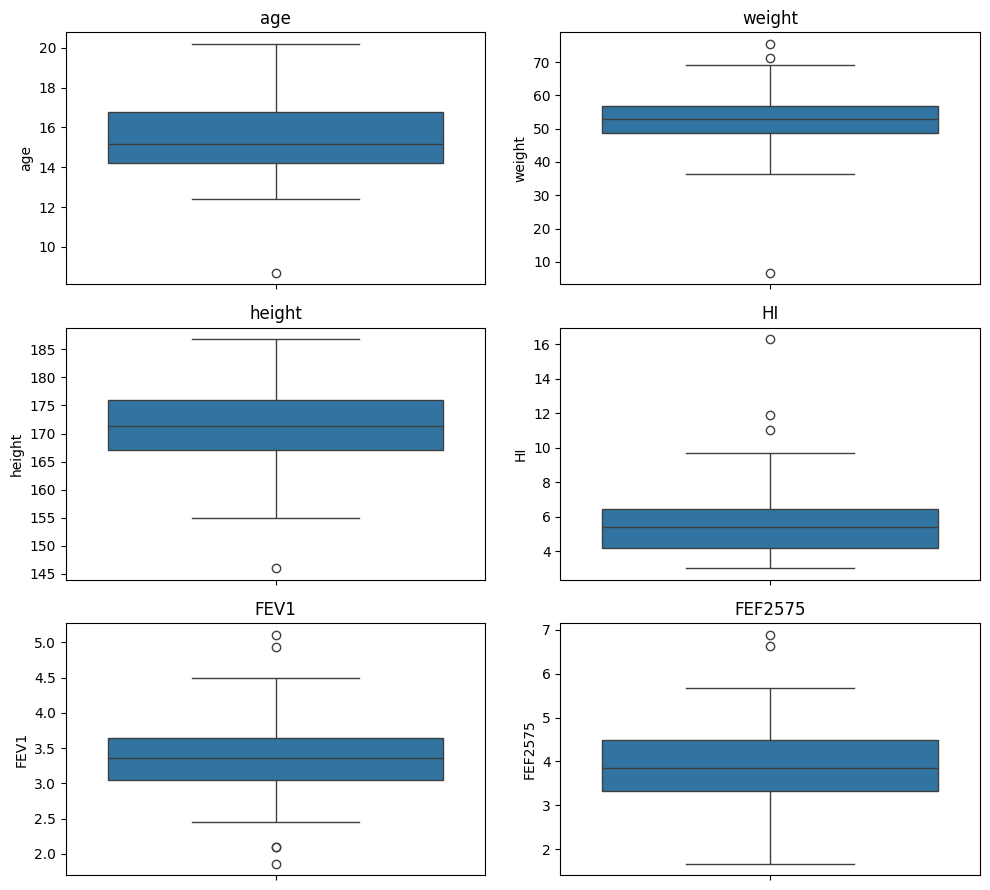

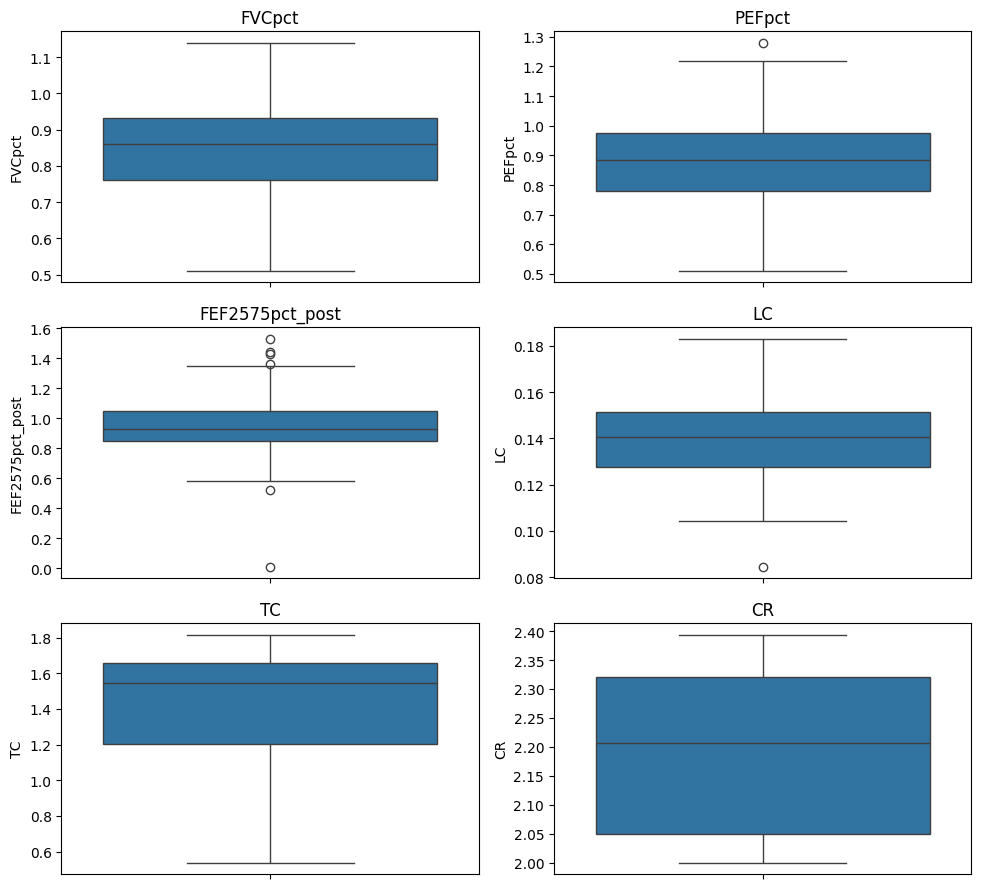

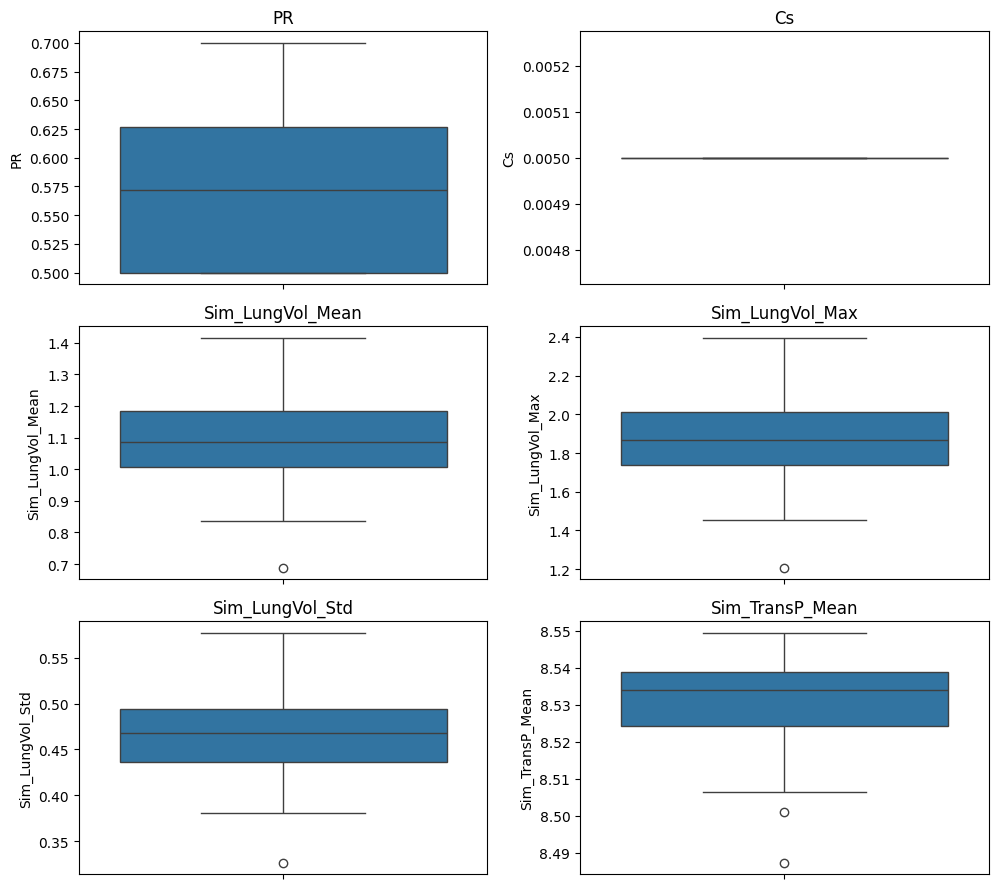

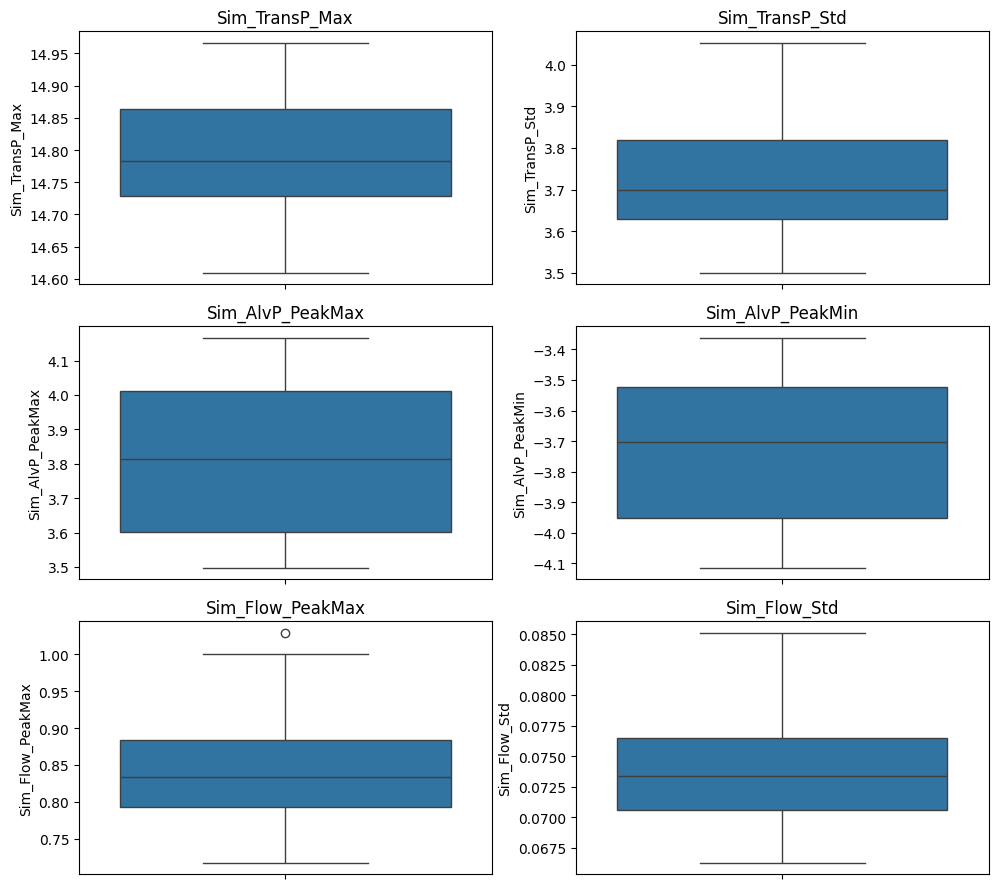

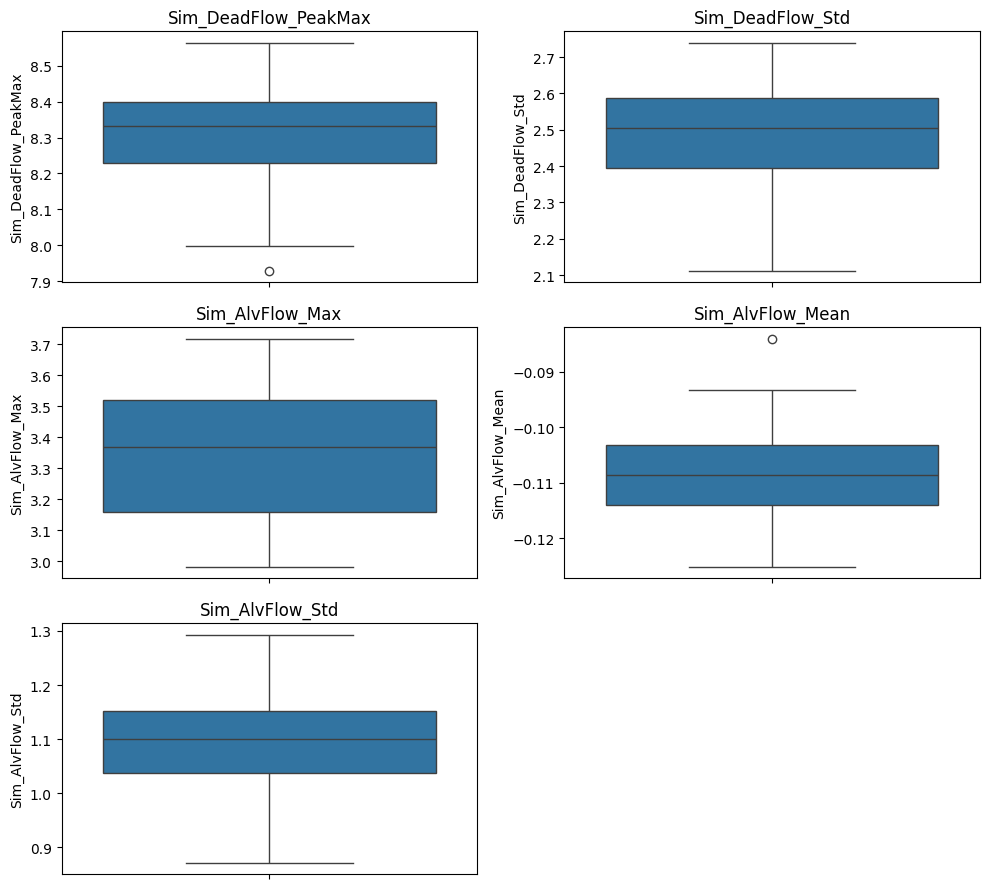

In [ ]:


# Select only numerical columns
num_cols = pe_cluster.select_dtypes(include=['int64', 'float64']).columns

# Set number of plots per figure
plots_per_fig = 6
num_figs = math.ceil(len(num_cols) / plots_per_fig)

for i in range(num_figs):
    subset = num_cols[i*plots_per_fig:(i+1)*plots_per_fig]
    n_rows = math.ceil(len(subset) / 2)  # 2 columns per row

    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3*n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, subset):
        sns.boxplot(y=pe_cluster[col], ax=ax)
        ax.set_title(f'{col}')

    # Hide any unused subplots
    for j in range(len(subset), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


#### Insights
##### Approximate Normal:
- Age,
- weight,
- height,
- HI,
- FEV1,
- FEF2575,
- PEFpct,
- LC,
- PR,
- Sim_LungVol_Mean,
- Sim_Lung_Vol_Max,
- Sim_LungVol_Std, Sim_Alvp_PeakMax,
- Sim_AlvP_PeakMin,
- Sim_flow_PeakMax,
- Sim_flow_std,
- Sim_AlvFlow_Std,
- Sim_AlvFlow_Mean,
- Sim_Dead_Flow_PeakMax,
- Sim_Deadflow_std
##### Skew Distr:
- FVCpct,
- FEF2577,
- TC,
- CR,
- Sim_TransP_mean,
- Sim_TransP_Max,
- Sim_TransP_std,
- Sim_Alvflow_Max
##### Outliers:
- There is one outlier that some teenager age is < 20 pounds
- The remaining outliers are in the acceptable range for clinical data (proof?)

#### Summary:
- Since there are columns with **Skew Normal distribution**, and there are some columns with **outliers**, I will use **median (Robust Scaler) to scale the data**. This method is robust to outliers and skewed columns, also worked well for normal distribution data

In [ ]:
# Outlier data
pe[pe['weight'] < 20]

# The weight is 6.7 for a age 18 teenager, this must be an error, will impute this later

,patientIndex,age,gender,weight,height,HI,FEV1,FEF2575,FVCpct,PEFpct,...,Sim_TransP_Std,Sim_AlvP_PeakMax,Sim_AlvP_PeakMin,Sim_Flow_PeakMax,Sim_Flow_Std,Sim_DeadFlow_PeakMax,Sim_DeadFlow_Std,Sim_AlvFlow_Max,Sim_AlvFlow_Mean,Sim_AlvFlow_Std
14,15,18.3,Male,6.7,178.3,5.4,3.52,3.01,0.83,0.75,...,3.5559,3.498,-3.362,0.9024,0.076,8.1829,2.5942,3.0507,-0.1033,1.0623


In [ ]:
# Age follow normal distribution, will use the mean to impute
pe.loc[pe['weight'] == 6.7, 'weight'] = pe['weight'].mean()


In [ ]:
to_standardize_cols = pe_cluster.drop(['gender'], axis = 1).columns
to_standardize_cols, len(to_standardize_cols)

(Index(['age', 'weight', 'height', 'HI', 'FEV1', 'FEF2575', 'FVCpct', 'PEFpct',
        'FEF2575pct_post', 'LC', 'TC', 'CR', 'PR', 'Cs', 'Sim_LungVol_Mean',
        'Sim_LungVol_Max', 'Sim_LungVol_Std', 'Sim_TransP_Mean',
        'Sim_TransP_Max', 'Sim_TransP_Std', 'Sim_AlvP_PeakMax',
        'Sim_AlvP_PeakMin', 'Sim_Flow_PeakMax', 'Sim_Flow_Std',
        'Sim_DeadFlow_PeakMax', 'Sim_DeadFlow_Std', 'Sim_AlvFlow_Max',
        'Sim_AlvFlow_Mean', 'Sim_AlvFlow_Std'],
       dtype='object'),
 29)

In [ ]:
# Initialize scaler
scaler = RobustScaler()

# Fit and transform the numeric columns
pe_cluster[to_standardize_cols] = scaler.fit_transform(pe_cluster[to_standardize_cols])

# verify scaling result
pe_cluster[to_standardize_cols].describe()

,age,weight,height,HI,FEV1,FEF2575,FVCpct,PEFpct,FEF2575pct_post,LC,...,Sim_TransP_Std,Sim_AlvP_PeakMax,Sim_AlvP_PeakMin,Sim_Flow_PeakMax,Sim_Flow_Std,Sim_DeadFlow_PeakMax,Sim_DeadFlow_Std,Sim_AlvFlow_Max,Sim_AlvFlow_Mean,Sim_AlvFlow_Std
count,6.000000e+01,6.000000e+01,6.000000e+01,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,6.000000e+01,...,60.000000,60.000000,6.000000e+01,60.000000,60.000000,60.000000,60.000000,60.000000,6.000000e+01,6.000000e+01
mean,1.215686e-01,-1.168177e-02,-3.379501e-02,0.161798,-0.031111,0.084665,-0.068599,-0.011966,0.147417,-3.457052e-02,...,0.090148,0.000456,-3.856440e-02,0.091537,0.020709,-0.118380,-0.045778,-0.038772,7.544265e-03,-4.757935e-02
std,7.752618e-01,1.217172e+00,8.630285e-01,1.019525,1.009957,0.836404,0.815060,0.788085,1.146656,8.079448e-01,...,0.668491,0.554017,5.401921e-01,0.743732,0.749147,0.788828,0.714738,0.597232,7.191286e-01,7.233305e-01
min,-2.529412e+00,-5.570997e+00,-2.808864e+00,-1.078652,-2.500000,-1.883369,-2.028986,-1.923077,-4.580000,-2.379639e+00,...,-1.054647,-0.769391,-9.522431e-01,-1.282705,-1.208511,-2.360944,-2.070387,-1.066392,-1.538106e+00,-2.008776e+00
25%,-3.725490e-01,-4.984894e-01,-4.819945e-01,-0.539326,-0.516667,-0.447084,-0.579710,-0.538462,-0.375000,-5.471898e-01,...,-0.363250,-0.516411,-5.786975e-01,-0.442905,-0.476596,-0.600498,-0.575968,-0.584124,-5.034642e-01,-5.506801e-01
50%,3.504141e-16,4.302114e-16,-1.575129e-15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.880713e-16,...,0.000000,0.000000,5.152129e-16,0.000000,0.000000,0.000000,0.000000,0.000000,6.418477e-16,9.744809e-16
75%,6.274510e-01,5.015106e-01,5.180055e-01,0.460674,0.483333,0.552916,0.420290,0.461538,0.625000,4.528102e-01,...,0.636750,0.483589,4.213025e-01,0.557095,0.523404,0.399502,0.424032,0.415876,4.965358e-01,4.493199e-01
max,1.980392e+00,2.743202e+00,1.711911e+00,4.898876,2.916667,2.626350,1.623188,2.025641,3.025000,1.806999e+00,...,1.880069,0.864006,7.903907e-01,2.171840,1.991489,1.363436,1.228365,0.956976,2.267898e+00,1.695480e+00


### Encode

In [ ]:
# Encode gender feature as 1, 0.
pe_cluster['gender'].unique() # Male and male. TODO

array(['Male', 'male', 'Female'], dtype=object)

In [ ]:
# Map male = 1, female = 0
mapping = {'Male': 1, 'Female': 0, 'male': 1}
pe_cluster['gender'] = pe_cluster['gender'].map(mapping)

#pe_cluster.head()


## 2. Understand the data

- Since the data is high dimension, we would like to understand the data by projecting it to a lower dimensional space

### PCA

[0.41505863 0.18013277 0.17341347]


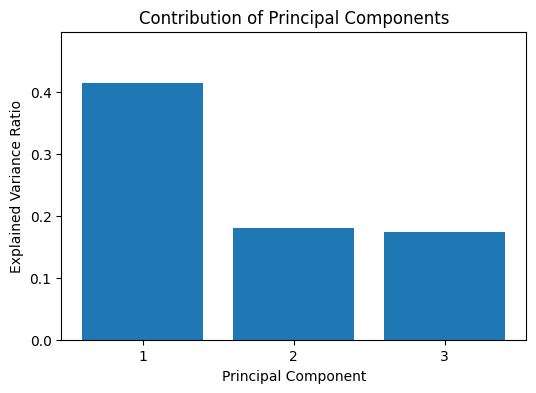

In [ ]:
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(pe_cluster)
# See explained variance
print(pca.explained_variance_ratio_)

explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.bar(
    x=np.arange(1, len(explained_variance_ratio) + 1),
    height=explained_variance_ratio
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Contribution of Principal Components")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1))
plt.ylim(0, max(explained_variance_ratio) * 1.2)

plt.show()

- The first 3 components **explained approx 80%** of the variance in the data

                         PC1     PC2     PC3
age                   0.4380 -0.1362  0.0947
gender                0.2910  0.2497 -0.0094
weight                0.6466  0.0874 -0.0617
height                0.7918 -0.3819  0.1866
HI                   -0.3928 -0.1810  0.0946
FEV1                  0.8932  0.1992 -0.0584
FEF2575               0.4785  0.5606  0.3530
FVCpct                0.4255  0.1756 -0.4813
PEFpct                0.3719  0.6525 -0.5757
FEF2575pct_post       0.0918  0.7706  0.5425
LC                    0.9432 -0.2681 -0.0699
TC                    0.1621  0.1904 -0.0408
CR                   -0.4001 -0.6614  0.6005
PR                   -0.2722 -0.7119 -0.5703
Cs                       NaN     NaN     NaN
Sim_LungVol_Mean      0.9597 -0.2338 -0.0614
Sim_LungVol_Max       0.9671 -0.2015 -0.0694
Sim_LungVol_Std       0.9819 -0.0730 -0.1030
Sim_TransP_Mean       0.7102 -0.3937  0.5276
Sim_TransP_Max       -0.7423  0.6182 -0.1239
Sim_TransP_Std       -0.7629  0.6121 -0.1366
Sim_AlvP_P

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


#### Correlation between PCs and Variables

In [ ]:
loadings = pca.components_.T
explained_var = pca.explained_variance_

corr_matrix = loadings * explained_var**0.5      ## corr(X_i, PC_k) =  loading_jk * sqrt(variance explained by PC)

corr_df = pd.DataFrame(
    corr_matrix,
    index=pe_cluster.columns,
    columns=[f"PC{i+1}" for i in range(corr_matrix.shape[1])]
)

print(corr_df.round(4))

                         PC1     PC2     PC3
age                   0.3396 -0.1056  0.0734
gender                0.1048  0.0899 -0.0034
weight                0.7871  0.1064 -0.0752
height                0.6834 -0.3296  0.1610
HI                   -0.4005 -0.1845  0.0964
FEV1                  0.9021  0.2012 -0.0590
FEF2575               0.4002  0.4689  0.2952
FVCpct                0.3468  0.1431 -0.3923
PEFpct                0.2931  0.5143 -0.4537
FEF2575pct_post       0.1053  0.8836  0.6221
LC                    0.7621 -0.2166 -0.0564
TC                    0.0958  0.1125 -0.0241
CR                   -0.2064 -0.3413  0.3098
PR                   -0.1420 -0.3715 -0.2976
Cs                   -0.0000  0.0000 -0.0000
Sim_LungVol_Mean      0.7760 -0.1891 -0.0497
Sim_LungVol_Max       0.8076 -0.1682 -0.0580
Sim_LungVol_Std       0.8065 -0.0600 -0.0846
Sim_TransP_Mean       0.5864 -0.3251  0.4356
Sim_TransP_Max       -0.4912  0.4091 -0.0820
Sim_TransP_Std       -0.5100  0.4092 -0.0913
Sim_AlvP_P

In [ ]:
X_scaled_df = pe_cluster.copy()
pc_scores = X_scaled_df @ pca.components_.T

# Compute correlation matrix between features and PCs
corr_matrix = np.corrcoef(X_scaled_df.T, pc_scores.T)[
    :X_scaled_df.shape[1],   # top block: features
    X_scaled_df.shape[1]:    # right block: PCs
]

corr_df = pd.DataFrame(
    corr_matrix,
    index=X_scaled_df.columns,
    columns=[f"PC{i+1}" for i in range(pc_scores.shape[1])]
)

print(corr_df.round(4))

                         PC1     PC2     PC3
age                   0.4380 -0.1362  0.0947
gender                0.2910  0.2497 -0.0094
weight                0.6466  0.0874 -0.0617
height                0.7918 -0.3819  0.1866
HI                   -0.3928 -0.1810  0.0946
FEV1                  0.8932  0.1992 -0.0584
FEF2575               0.4785  0.5606  0.3530
FVCpct                0.4255  0.1756 -0.4813
PEFpct                0.3719  0.6525 -0.5757
FEF2575pct_post       0.0918  0.7706  0.5425
LC                    0.9432 -0.2681 -0.0699
TC                    0.1621  0.1904 -0.0408
CR                   -0.4001 -0.6614  0.6005
PR                   -0.2722 -0.7119 -0.5703
Cs                       NaN     NaN     NaN
Sim_LungVol_Mean      0.9597 -0.2338 -0.0614
Sim_LungVol_Max       0.9671 -0.2015 -0.0694
Sim_LungVol_Std       0.9819 -0.0730 -0.1030
Sim_TransP_Mean       0.7102 -0.3937  0.5276
Sim_TransP_Max       -0.7423  0.6182 -0.1239
Sim_TransP_Std       -0.7629  0.6121 -0.1366
Sim_AlvP_P

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]




**PC1: Overall lung function + size vs PE severity**

**Simple term: Overall lung function - how much air your lungs can move and how severve is your PE**

Strong positive weights (big contributors):
- Lung function: FEV1 (0.90)
- Body size: weight (0.78), height (0.70)
- Mechanics/volume: Lung_Compliance (LC) (0.77), Sim_LungVol_Mean/Max/Std (~0.78–0.81)

Strong negatives:
- HI (-0.40) - more severe pectus

Intepretation:
- **High PC1**: Good lung function, bigger body size, good lung flexibility, high lung volume

- **Low PC1**: Bad lung function, more severe PE

-----------------

**PC2: Expiratory flow & small-airway performance / bronchodilator response**

**Simple term: Performance of small-airway ; measures how strong and fast the air moves out of the system during exhalation**

Strong positive weights:

- FEF2575pct_post (0.96)
  - *how well small airways blow air out after they are open*  - main contributor

- FEF2575 (0.52)


Strong negatives:

- Peripheral Resistance (PR) (-0.42)
  - *resistance in the smaller, deeper airway*

- Sim_AlvP_PeakMin (-0.43)
  - *how hard you lungs have to "pull" to get air out. More negative = harder, less efficient airflow.*

Intepretation:
- **High PC2**: strong, fast airflow and low resistance
- **Low PC2**: weak airflow and high resistance
------------------------
**PC3: Effective main airway flow vs dead-space / wasted ventilation**

**Simple term: How efficient is your airflow is vs how much is wasted” (dead-space, inefficiency)**

Strong positives:

- Sim_DeadFlow_PeakMax (0.70)
  - The amount of airflow that goes into "dead space" - air that doesn't reach the useful part of the lungs.


Strong negatives:

- Sim_Flow_PeakMax (-0.67)
  - Maximum "useful" airflow (stronger -> more efficient breathing)

- PEFpct (-0.52), FVCpct (-0.41)
  - Also measure how efficient your airflow is

Intepretation:

- **High PC3** = more dead-space flow-> **less efficient ventilation / more wasted breath.**

- **Low PC3** = strong main airway peak flow, better PEF/FVC -> **more efficient, effective flow.**

---------------
**Summary**:

- PC1: overall lung size & global function vs PE severity

- PC2: small-airway performance

- PC3: Airflow efficiency (dead-space vs effective flow).

-> Having this intepretation for this PC, we can make a pairwise plot between the components to understand more about data


References: https://online.stat.psu.edu/stat505/lesson/11/11.6

#### Plot between PCs

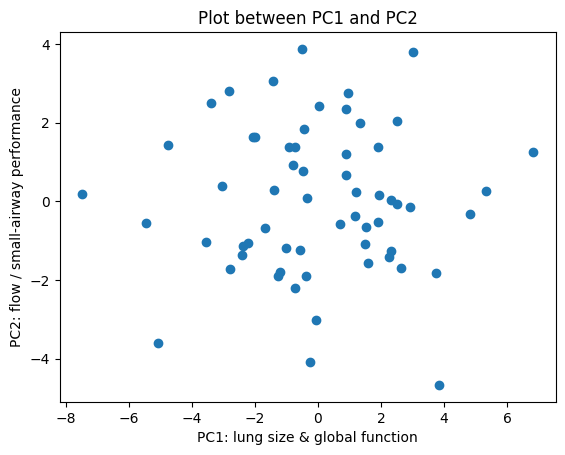

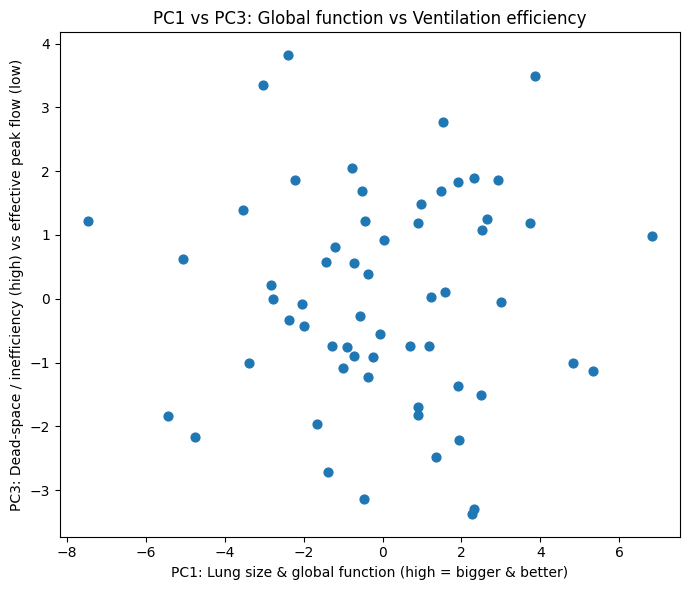

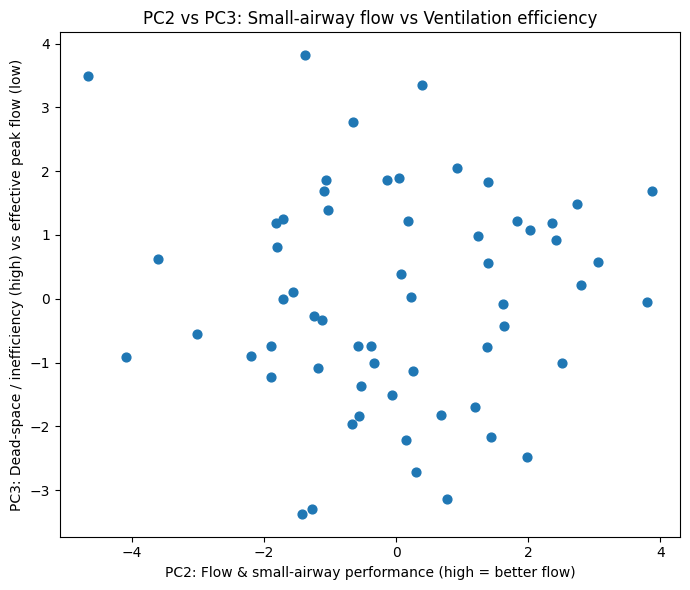

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1: lung size & global function")
plt.ylabel("PC2: flow / small-airway performance")
plt.title("Plot between PC1 and PC2")



# --- PC1 vs PC3 ---
plt.figure(figsize=(7, 6))
plt.scatter(
    X_pca[:, 0],   # PC1
    X_pca[:, 2],   # PC3
    s=40
)
plt.xlabel("PC1: Lung size & global function (high = bigger & better)")
plt.ylabel("PC3: Dead-space / inefficiency (high) vs effective peak flow (low)")
plt.title("PC1 vs PC3: Global function vs Ventilation efficiency")
plt.tight_layout()
plt.show()

# --- PC2 vs PC3 ---
plt.figure(figsize=(7, 6))
plt.scatter(
    X_pca[:, 1],   # PC2
    X_pca[:, 2],   # PC3
    s=40
)
plt.xlabel("PC2: Flow & small-airway performance (high = better flow)")
plt.ylabel("PC3: Dead-space / inefficiency (high) vs effective peak flow (low)")
plt.title("PC2 vs PC3: Small-airway flow vs Ventilation efficiency")
plt.tight_layout()
plt.show()


##### Intepretation for PC1 vs PC2
- Top-right (high PC1, high PC2)
-> big lungs, good FEV1, good flows -> best overall function

- Top-left (low PC1, high PC2)
-> smaller / more impaired lungs but still decent flows -> compensated?

- Bottom-right (high PC1, low PC2)
-> good lung size, but poor flows / higher resistance -> possible obstruction

- Bottom-left (low PC1, low PC2)
-> small lungs + poor flows → worst group


##### Intepretation for PC1 vs PC3
- High PC1, Low PC3
-> big, well-functioning lungs + efficient flow
->“best” profile

- High PC1, High PC3
->big lungs but a lot of wasted/dead-space ventilation
->capacity OK, efficiency bad

- Low PC1, Low PC3
-> small lungs but relatively efficient given size
->restricted but efficient

- Low PC1, High PC3
->small lungs + wasted ventilation
->“worst” profile (most impaired)

##### Intepretation for PC2 and PC3

- High PC2, Low PC3
→ good flow + efficient ventilation
→ good small-airway function & efficient mechanics

- High PC2, High PC3
-> good flows but still a lot of dead-space / pressure issues
->compensated but inefficient

- Low PC2, Low PC3
->poor flow but relatively efficient mechanics
->maybe mildly impaired

- Low PC2, High PC3
->poor flows + wasted ventilation
->most problematic group here


## 3D Clustering Plotting
## Alan Pham

## Data Points

## K-Means Clustering

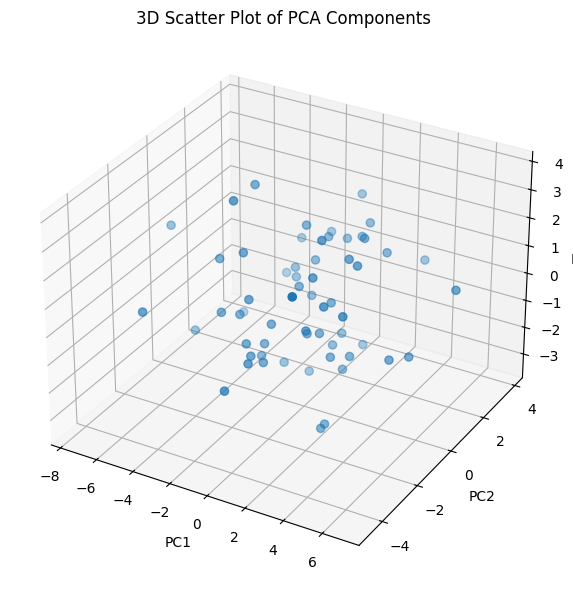

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

PC1 = X_pca[:, 0]
PC2 = X_pca[:, 1]
PC3 = X_pca[:, 2]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(PC1, PC2, PC3, s=35)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Scatter Plot of PCA Components")

plt.tight_layout()
plt.show()

/tmp/ipython-input-2739986812.py:20: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



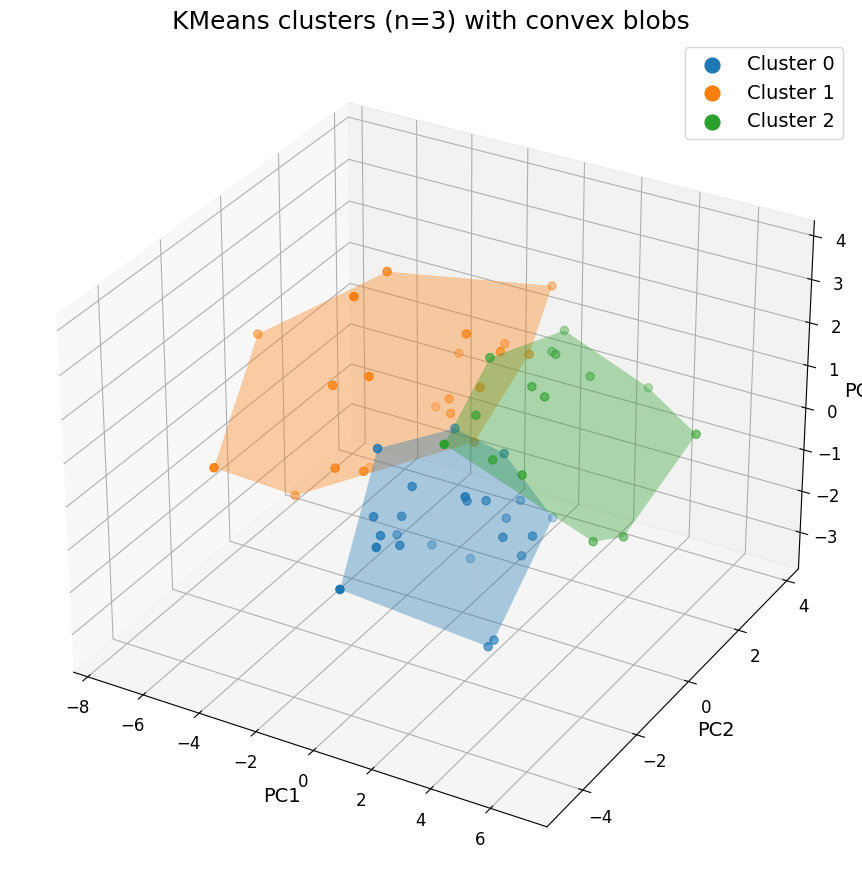

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
from sklearn.cluster import KMeans
import matplotlib.cm as cm
import numpy as np

n_clusters = 3
random_state = 0
alpha_blob = 0.20
marker_size = 35

kmeans_model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
labels = kmeans_model.fit_predict(X_pca[:, :3])

df = pd.DataFrame(X_pca[:, :3], columns=['PC1','PC2','PC3'])
df['label'] = labels

fig = plt.figure(figsize=(11,9))
ax = fig.add_subplot(111, projection='3d')
colors = cm.get_cmap('tab10')(np.linspace(0,1, max(n_clusters,10)))

for label in np.unique(labels):
    pts = df[df['label']==label][['PC1','PC2','PC3']].values
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=marker_size, label=f'Cluster {label}', color=colors[label % len(colors)])
    if pts.shape[0] >= 4:
        try:
            hull = ConvexHull(pts)
            faces = []
            for simplex in hull.simplices:
                faces.append(pts[simplex])
            poly = Poly3DCollection(faces, alpha=alpha_blob, facecolor=colors[label % len(colors)], edgecolor=None)
            ax.add_collection3d(poly)
        except Exception as e:
            if pts.shape[0] >= 3:
                try:
                    from scipy.spatial import ConvexHull as CH2
                    hull2 = CH2(pts[:, :2])
                    verts2 = pts[hull2.vertices, :2]
                    z_mean = pts[:,2].mean()
                    verts3 = [list(zip(verts2[:,0], verts2[:,1], [z_mean]*len(verts2)))]
                    poly = Poly3DCollection(verts3, alpha=alpha_blob, facecolor=colors[label % len(colors)], edgecolor=None)
                    ax.add_collection3d(poly)
                except Exception:
                    pass
    elif pts.shape[0] == 3:
        verts = [pts]
        poly = Poly3DCollection(verts, alpha=alpha_blob, facecolor=colors[label % len(colors)], edgecolor=None)
        ax.add_collection3d(poly)

ax.set_xlabel('PC1', fontsize = 14)
ax.set_ylabel('PC2', fontsize = 14)
ax.set_zlabel('PC3', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='z', labelsize=12)

ax.set_title(f'KMeans clusters (n={n_clusters}) with convex blobs', fontsize = 18)
ax.legend(loc='best', fontsize=14, markerscale=1.8)

plt.tight_layout()
plt.show()

In [ ]:
print("Centroids in Kmeans space:")
centroids = kmeans_model.cluster_centers_
print(pd.DataFrame(centroids, columns=["PC1", "PC2", "PC3"]))

Centroids in Kmeans space:
        PC1       PC2       PC3
0  0.392171 -0.768128 -1.309543
1 -2.578651  0.713809  0.615058
2  2.982639  0.229673  1.234189


## Agglomerative Clustering

/tmp/ipython-input-3626025273.py:17: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



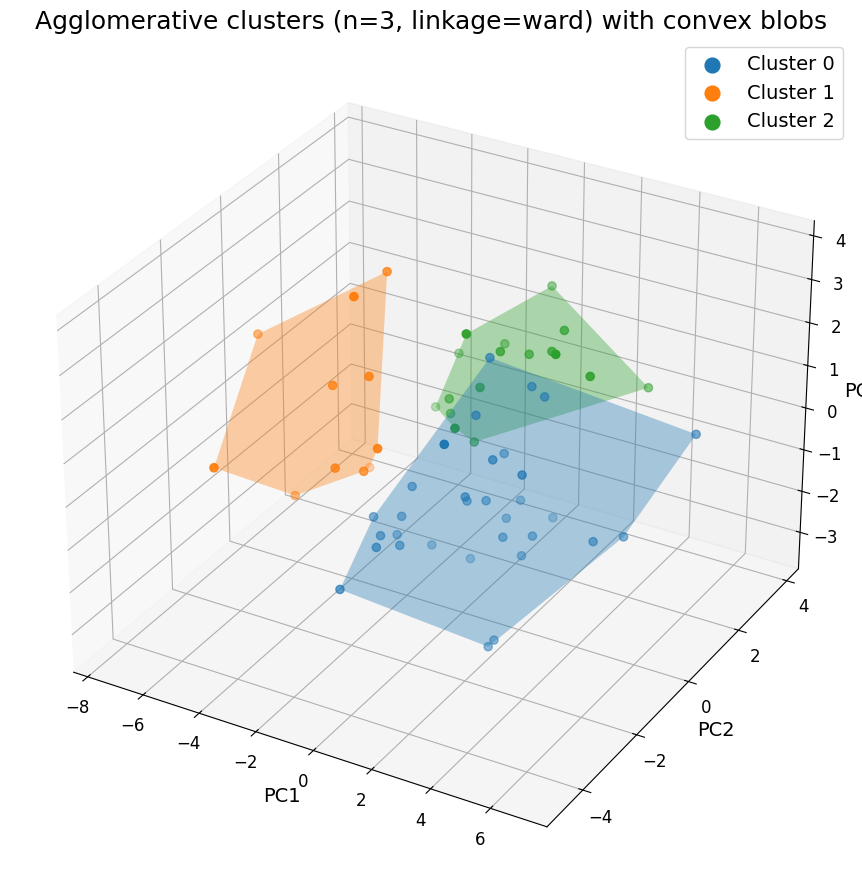

In [ ]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 3
linkage_method = 'ward'
alpha_blob = 0.20
marker_size = 35

agg_model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method)
labels = agg_model.fit_predict(X_pca[:, :3])

df = pd.DataFrame(X_pca[:, :3], columns=['PC1','PC2','PC3'])
df['label'] = labels


fig = plt.figure(figsize=(11,9))
ax = fig.add_subplot(111, projection='3d')
colors = cm.get_cmap('tab10')(np.linspace(0,1, max(n_clusters,10)))

for label in np.unique(labels):
    pts = df[df['label']==label][['PC1','PC2','PC3']].values
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=marker_size, label=f'Cluster {label}', color=colors[label % len(colors)])

    if pts.shape[0] >= 4:
        try:
            hull = ConvexHull(pts)
            faces = []
            for simplex in hull.simplices:
                faces.append(pts[simplex])
            poly = Poly3DCollection(faces, alpha=alpha_blob, facecolor=colors[label % len(colors)], edgecolor=None)
            ax.add_collection3d(poly)
        except Exception:
            if pts.shape[0] >= 3:
                try:
                    from scipy.spatial import ConvexHull as CH2
                    hull2 = CH2(pts[:, :2])
                    verts2 = pts[hull2.vertices, :2]
                    z_mean = pts[:,2].mean()
                    verts3 = [list(zip(verts2[:,0], verts2[:,1], [z_mean]*len(verts2)))]
                    poly = Poly3DCollection(verts3, alpha=alpha_blob, facecolor=colors[label % len(colors)], edgecolor=None)
                    ax.add_collection3d(poly)
                except Exception:
                    pass
    elif pts.shape[0] == 3:
        verts = [pts]
        poly = Poly3DCollection(verts, alpha=alpha_blob, facecolor=colors[label % len(colors)], edgecolor=None)
        ax.add_collection3d(poly)

ax.set_xlabel('PC1', fontsize = 14)
ax.set_ylabel('PC2', fontsize = 14)
ax.set_zlabel('PC3', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='z', labelsize=12)

ax.set_title(f'Agglomerative clusters (n={n_clusters}, linkage={linkage_method}) with convex blobs', fontsize = 18)
ax.legend(loc='best', fontsize=14, markerscale=1.8)
plt.tight_layout()
plt.show()


## 3D clustering v0.2

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

#Interactive plot
import plotly.express as px
from scipy.spatial import ConvexHull
import plotly.graph_objects as go

# Scoring metric for Kmeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

### Methods:
- Use K-means assumes
  - clusters are similar variance, density,
  - roughly circular (2d) or hyperspherical

- Use Agglomerative:
  - Don't know the number of clusters
  - Cluster are not spherical (irregular shapes)
  - Good for medical data with complex structure

### K-means

- We will use Elbow Method, Silhoutte Score, Calinski-Harbasz Index to choose the best number of cluster (k)

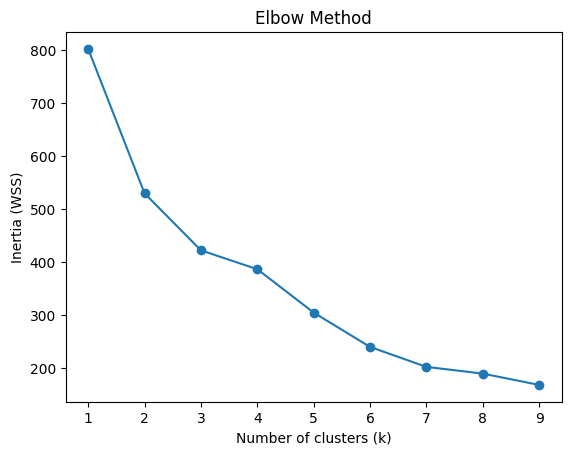

[802.309825051682,
 529.5791740081281,
 422.03037351432096,
 386.4226929427045,
 304.5040007198726,
 239.7051868619738,
 201.9962384795368,
 189.31387502613788,
 167.93270893469503]

In [ ]:
# Elbow method

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  # use your 3 PCs
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WSS)")
plt.title("Elbow Method")
plt.show()
inertia

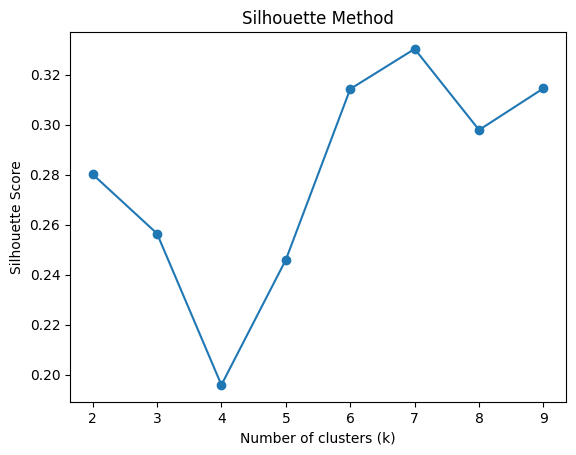

[np.float64(0.2801678267330967),
 np.float64(0.2564597790402637),
 np.float64(0.19590213981906193),
 np.float64(0.24592570403709427),
 np.float64(0.3142491585084843),
 np.float64(0.3302771922043426),
 np.float64(0.2978645841388582),
 np.float64(0.314519270717142)]

In [ ]:
# Sihoutte Score (Separation + Compactnestt)
sil = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil.append(silhouette_score(X_pca, labels))

plt.plot(K, sil, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()
sil

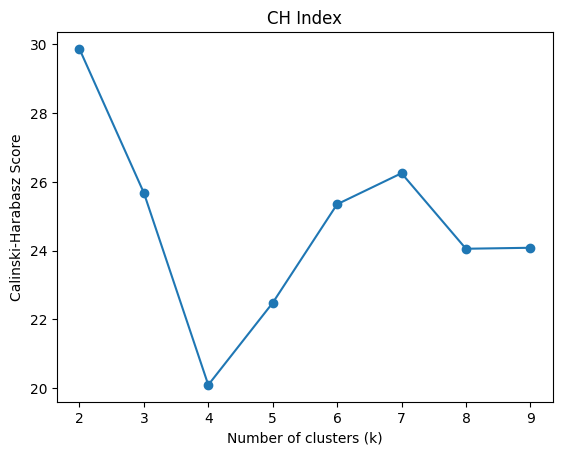

[np.float64(29.86971266412253),
 np.float64(25.680531660707672),
 np.float64(20.089985934613114),
 np.float64(22.478621195060306),
 np.float64(25.34834632488612),
 np.float64(26.25182555197835),
 np.float64(24.05362100142446),
 np.float64(24.081991774565285)]

In [ ]:


ch_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

plt.plot(K, ch_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("CH Index")
plt.show()

ch_scores


#### Choosing K:
- Although k=2 maximized the Calinski-Harabasz index, the elbow in enertia occured around k = 3, and the silhoutte score at k = 3 (0.26) remained comparable to k = 2 (0.28); even though k = 7 maximized the silhoutte score.
- Given the trade-off between **statistical fit** and **clinical interpretability**, I choose k=3 because it offered a better balance between structure and interpretability

#### Fitting K-means with K = 3

In [ ]:

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df_pca_kmeans = pd.DataFrame(X_pca, columns=['PC1','PC2','PC3'])
df_pca_kmeans['cluster'] = clusters



In [ ]:
fig = go.Figure()

point_colors = {
    0: "red",
    1: "green",
    2: "blue"
}

colors = {0: "rgba(255,0,0,255)",
          1: "rgba(0,255,0,255)",
          2: "rgba(0,0,255,255)"}

# Add point scatter
fig.add_trace(go.Scatter3d(
    x=df_pca_kmeans["PC1"],
    y=df_pca_kmeans["PC2"],
    z=df_pca_kmeans["PC3"],
    mode="markers",
    marker=dict(
    size=4,
    color=df_pca_kmeans["cluster"].map(point_colors)
),
    name="Points"
))

# Add convex hull for each cluster
for c in df_pca_kmeans["cluster"].unique():
    points = df_pca_kmeans[df_pca_kmeans["cluster"] == c][["PC1","PC2","PC3"]].values

    if len(points) >= 4:  # convex hull needs >=4 points
        hull = ConvexHull(points)
        vertices = hull.vertices

        fig.add_trace(go.Mesh3d(
            x=points[vertices, 0],
            y=points[vertices, 1],
            z=points[vertices, 2],
            opacity=0.2,
            color=colors[c],
            name=f"Cluster {c} Hull"
        ))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1: Lung global function & Body size",
        yaxis_title="PC2: Airflow strength",
        zaxis_title="PC3: Airflow efficiency"
    ),
    width=900,
    height=800
)

fig.show()

#### Intepretation (TODO)

- Cluster 0 (Red): Bigger body size, strong lung size & global function, good airflow performance,  efficient gas exchange in the lung -> **(Good overall patient group)**

- Cluster 1 (Green): Weak lung size & global function, good airflow strength, ok/average airflow efficiency **(Good airflow strength, efficiency patient, weak lung, gloabal function/ more servere PE patients) -> Average severity group**

- Cluster 2 (Purple): normal lung size & global function, Bad airflow strength, Bad airflow efficiency -> **(Worst severity group)**

-> **Very good for separating patient groups based on the severity**

- Clustering 0 (Red): Good global lung function, good airflow performance and efficiency -> **Good overall patient group**
- Clustering 1 (Green): Bad global lung function, good airflow performance and efficiency,  -> **Average severity group**
- Clustering 2 (Green): Bad airflow performance and efficiency -> **Worst severity group**

### Agglomerative Clustering

#### Choosing K

> Add blockquote



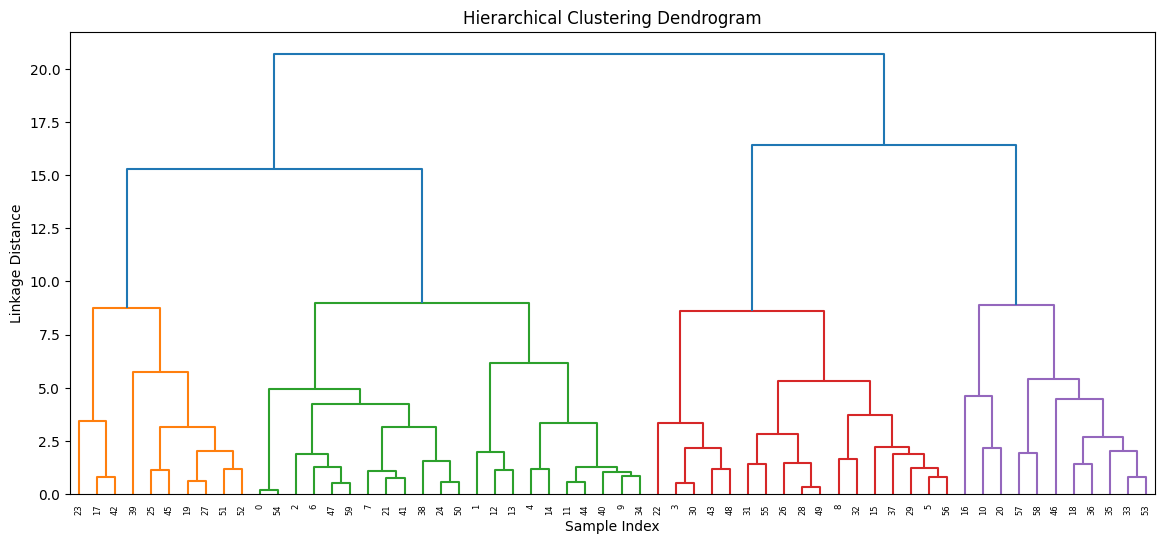

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Use your PCA data
X = X_pca

# Compute the linkage matrix
Z = linkage(X, method='ward')  # "ward" works great for Euclidean distances

# Plot the dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode=None, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Linkage Distance")
plt.show()


- Will perform Agglomerative Clustering with K = 3 (TODO EXPLANATION WHY)

#### Fitting and plotting Agglomerative clustering with K = 3

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=3,        # same as K-means choice
    linkage='ward'       # Ward is best for continuous data + PCA
)

clusters = agg.fit_predict(X_pca)

# Build the PCA dataframe with cluster labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['cluster'] = clusters

df_pca.head()

,PC1,PC2,PC3,cluster
0,2.313153,-1.270010,-3.300314,0
1,-1.674797,-0.666964,-1.960719,0
2,1.580921,-1.569579,0.105827,0
3,0.962410,2.742576,1.490440,2
4,-0.060141,-3.016643,-0.551096,0


In [ ]:
fig = go.Figure()

colors = {0: "rgba(255,0,0,0.3)",
          1: "rgba(0,255,0,0.3)",
          2: "rgba(0,0,255,0.3)"}

# Add point scatter
fig.add_trace(go.Scatter3d(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    z=df_pca["PC3"],
    mode="markers",
    marker=dict(size=4, color=df_pca["cluster"], colorscale="Viridis"),
    name="Points"
))

# Add convex hull for each cluster
for c in df_pca["cluster"].unique():
    points = df_pca[df_pca["cluster"] == c][["PC1","PC2","PC3"]].values

    if len(points) >= 4:  # convex hull needs >=4 points
        hull = ConvexHull(points)
        vertices = hull.vertices

        fig.add_trace(go.Mesh3d(
            x=points[vertices, 0],
            y=points[vertices, 1],
            z=points[vertices, 2],
            opacity=0.2,
            color=colors[c],
            name=f"Cluster {c} Hull"
        ))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1: Lung size & global function",
        yaxis_title="PC2: Airflow strength",
        zaxis_title="PC3: Airflow efficiency"
    ),
    width=900,
    height=800
)

fig.show()

#### Intepretation
- Cluster 0 (Red): Strong lung size & global function, Below average (weak) airflow strength,  Below average (weak) airflow effciency

- Cluster 1 (Green): Weak lung size & global function, normal airflow strength, above average (strong) airflow efficiency

- Cluster 2 (Purple): normal lung size & global function, Good airflow strength, normal airflow efficiency,

-> Not really separate groups

# Cluster Hypothesis Testing
Andrew Nguyen

**Goals for hypothesis testing:**

1. for each determined cluster, can we determine columns in which define the clusters statistically significant from each other?
2. we want to connect the patients back to their original and raw data
3. Run non-parametric tests to determine significance


**Justification on Nonparametric Methods**

Our patient dataset cannot be assumed to be normal, we are working with a rare case and furthermore our dataset is not large enough (even smaller per cluster!) to be generalized as a normal distribution

**Possible Tests**

Kruskal-Wallis Test
- Analyzes differences between means of given groups (non-parametric alternative to ANOVA)
- Benefit is that this test is designed for > 2 groups
- Hypotheses:
  - $H_o$ : Medians of each group are the same
  - $H_1$ : At least one of the group has a different median

Mann-Whitney Test
- Nonparametric alternative to t-test
- Will be used should the kruskal wallis test pass


In [ ]:
from scipy.stats import kruskal, mannwhitneyu, shapiro
from itertools import combinations

# from skbio.stats.distance import DistanceMatrix
# from skbio.stats.distance import permanova
# from scipy.spatial.distance import pdist, squareform
import scikit_posthocs as sp


In [ ]:
!pip install scikit-posthocs

In [ ]:
df_pca_kmeans.head()

,PC1,PC2,PC3,cluster
0,2.313153,-1.270010,-3.300314,2
1,-1.674797,-0.666964,-1.960719,1
2,1.580921,-1.569579,0.105827,2
3,0.962410,2.742576,1.490440,0
4,-0.060141,-3.016643,-0.551096,2


In [ ]:
df_pe_cluster = pe.merge(df_pca_kmeans, left_index=True, right_index=True)
df_pe_cluster.head()

,patientIndex,age,gender,weight,height,HI,FEV1,FEF2575,FVCpct,PEFpct,...,Sim_Flow_Std,Sim_DeadFlow_PeakMax,Sim_DeadFlow_Std,Sim_AlvFlow_Max,Sim_AlvFlow_Mean,Sim_AlvFlow_Std,PC1,PC2,PC3,cluster
0,1,15.6,Male,62.9,185.5,6.7,3.29,4.74,0.59,0.63,...,0.0671,8.3437,2.5321,3.1133,0.0175,1.0201,2.313153,-1.270010,-3.300314,2
1,2,16.1,Male,51.1,173.2,8.2,2.94,3.98,0.59,0.70,...,0.0694,8.3640,2.3218,3.1056,0.0077,0.9352,-1.674797,-0.666964,-1.960719,1
2,3,14.8,Male,56.9,175.5,5.7,3.14,3.35,0.89,0.89,...,0.0738,8.1737,2.3909,3.2631,0.0145,1.0408,1.580921,-1.569579,0.105827,2
3,4,15.1,male,54.4,166.0,4.4,4.05,4.86,1.05,1.04,...,0.0716,8.3135,2.2451,3.6939,0.0063,1.0730,0.962410,2.742576,1.490440,0
4,5,16.2,Male,53.9,178.0,5.5,2.70,2.49,0.66,0.78,...,0.0749,8.1534,2.3577,3.0587,0.0128,0.9697,-0.060141,-3.016643,-0.551096,2


In [ ]:
df_pe_cluster.columns

Index(['patientIndex', 'age', 'gender', 'weight', 'height', 'HI', 'FEV1',
       'FEF2575', 'FVCpct', 'PEFpct', 'FEF2575pct_post', 'LC', 'TC', 'CR',
       'PR', 'Cs', 'Sim_LungVol_Mean', 'Sim_LungVol_Max', 'Sim_LungVol_Std',
       'Sim_TransP_Mean', 'Sim_TransP_Max', 'Sim_TransP_Std',
       'Sim_AlvP_PeakMax', 'Sim_AlvP_PeakMin', 'Sim_Flow_PeakMax',
       'Sim_Flow_Std', 'Sim_DeadFlow_PeakMax', 'Sim_DeadFlow_Std',
       'Sim_AlvFlow_Max', 'Sim_AlvFlow_Mean', 'Sim_AlvFlow_Std', 'PC1', 'PC2',
       'PC3', 'cluster'],
      dtype='object')

In [ ]:
df_pe_cluster['cluster'].value_counts()

,count
cluster,
2,21
1,21
0,16


# Principal Component #1
From Minh's analysis, we can see that the top contributors to PC #1 are `FEV1` and Haller Index

In [ ]:
labels = df_pe_cluster["cluster"]

cols = ["FEV1", "HI", "weight", "height"]

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

FEV1 10.058043268301057 0.006545211050002166
HI 0.01449655374962322 0.992777928531111
weight 10.518058116763246 0.00520035150594818
height 11.657587334804676 0.0029416234169202557


At least one group's FEV1 median is statistically significant from the others

All groups share the same median for HI

In [ ]:
cols = ["FEV1", "weight", "height"]

groups_list = [0, 1, 2]

results = {}

for col in cols:
    results[col] = {}
    for g1, g2 in combinations(groups_list, 2):
        x = df_pe_cluster.loc[df_pe_cluster["cluster"] == g1, col].dropna()
        y = df_pe_cluster.loc[df_pe_cluster["cluster"] == g2, col].dropna()

        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        results[col][(g1, g2)] = (stat, p)

for col, pair_dict in results.items():
    print(col)
    for (g1, g2), (stat, p) in pair_dict.items():
        print(f"  {g1} vs {g2}: stat={stat}, p={p}")


FEV1
  0 vs 1: stat=255.5, p=0.007642417815118464
  0 vs 2: stat=164.0, p=0.9145363335402288
  1 vs 2: stat=112.0, p=0.006586862422311046
weight
  0 vs 1: stat=218.5, p=0.12524605022165938
  0 vs 2: stat=109.0, p=0.0728698174275903
  1 vs 2: stat=98.0, p=0.002141512001592797
height
  0 vs 1: stat=206.0, p=0.25001281477195847
  0 vs 2: stat=112.0, p=0.08874279763550386
  1 vs 2: stat=81.5, p=0.0004930693143302648


In [ ]:

cols = ["FEV1", "weight", "height"]
labels = df_pe_cluster["cluster"]

for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)



Dunn post-hoc for FEV1:
          0         1         2
0  1.00000  0.028210  1.000000
1  0.02821  1.000000  0.014446
2  1.00000  0.014446  1.000000

Dunn post-hoc for weight:
           0         1         2
0  1.000000  0.506903  0.304636
1  0.506903  1.000000  0.003589
2  0.304636  0.003589  1.000000

Dunn post-hoc for height:
           0         1         2
0  1.000000  0.577078  0.189408
1  0.577078  1.000000  0.002022
2  0.189408  0.002022  1.000000


Cluster 1 vs. 2 show the strongest separation between the other 2.

O and 1 are very similar, in the sense that height and weight show little variation but mostly divver in FEV1

# Principal Component #2
From Minh's analysis, we can see that the top contributors to PC #2 are `FEV25-75_post`

In [ ]:
cols = ["FEF2575pct_post", "FEF2575"]

results = {}

for col in cols:
    groups = [df_pe_cluster.loc[labels == g, col].dropna() for g in labels.unique()]

    # Kruskal–Wallis test
    stat, p = kruskal(*groups)
    results[col] = (stat, p)

for col, (stat, p) in results.items():
    print(col, stat, p)

FEF2575pct_post 9.098350658548814 0.010575922442229059
FEF2575 8.09305414229011 0.01748298649651312


In [ ]:
cols = ['FEF2575pct_post', 'FEF2575']

groups_list = [0, 1, 2]

results = {}

for col in cols:
    results[col] = {}
    for g1, g2 in combinations(groups_list, 2):
        x = df_pe_cluster.loc[df_pe_cluster["cluster"] == g1, col].dropna()
        y = df_pe_cluster.loc[df_pe_cluster["cluster"] == g2, col].dropna()

        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        results[col][(g1, g2)] = (stat, p)

for col, pair_dict in results.items():
    print(col)
    for (g1, g2), (stat, p) in pair_dict.items():
        print(f"  {g1} vs {g2}: stat={stat}, p={p}")


FEF2575pct_post
  0 vs 1: stat=243.0, p=0.022223831987091183
  0 vs 2: stat=266.0, p=0.002777378265635384
  1 vs 2: stat=218.5, p=0.9698793347103538
FEF2575
  0 vs 1: stat=244.0, p=0.02061223846564838
  0 vs 2: stat=255.5, p=0.007631632140876308
  1 vs 2: stat=214.0, p=0.8800033047080857


In [ ]:

cols = ['FEF2575pct_post', 'FEF2575']
labels = df_pe_cluster["cluster"]

for col in cols:
    data = df_pe_cluster[[col, "cluster"]].dropna()
    # Dunn's test with Bonferroni correction
    dunn_res = sp.posthoc_dunn(data, val_col=col, group_col="cluster", p_adjust='bonferroni')
    print(f"\nDunn post-hoc for {col}:\n", dunn_res)



Dunn post-hoc for FEF2575pct_post:
           0         1         2
0  1.000000  0.029195  0.018056
1  0.029195  1.000000  1.000000
2  0.018056  1.000000  1.000000

Dunn post-hoc for FEF2575:
           0         1         2
0  1.000000  0.034718  0.035998
1  0.034718  1.000000  1.000000
2  0.035998  1.000000  1.000000


# Principal Component #3
No largely contributing columns are phenotypes of patients (non-simulated), so no further testing

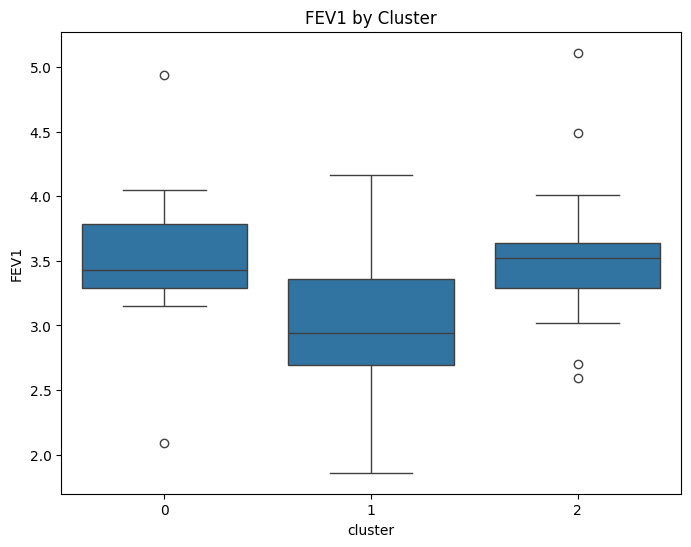

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x="cluster", y="FEV1", data=df_pe_cluster)
plt.xlabel("cluster")
plt.ylabel("FEV1")
plt.title("FEV1 by Cluster")
plt.show()

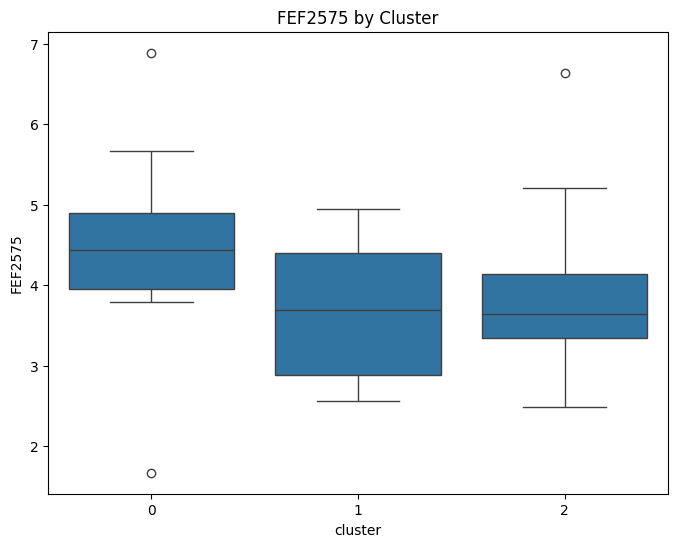

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x="cluster", y="FEF2575", data=df_pe_cluster)
plt.xlabel("cluster")
plt.ylabel("FEF2575")
plt.title("FEF2575 by Cluster")
plt.show()

In [ ]:
df_pe_cluster.columns

Index(['patientIndex', 'age', 'gender', 'weight', 'height', 'HI', 'FEV1',
       'FEF2575', 'FVCpct', 'PEFpct', 'FEF2575pct_post', 'LC', 'TC', 'CR',
       'PR', 'Cs', 'Sim_LungVol_Mean', 'Sim_LungVol_Max', 'Sim_LungVol_Std',
       'Sim_TransP_Mean', 'Sim_TransP_Max', 'Sim_TransP_Std',
       'Sim_AlvP_PeakMax', 'Sim_AlvP_PeakMin', 'Sim_Flow_PeakMax',
       'Sim_Flow_Std', 'Sim_DeadFlow_PeakMax', 'Sim_DeadFlow_Std',
       'Sim_AlvFlow_Max', 'Sim_AlvFlow_Mean', 'Sim_AlvFlow_Std', 'PC1', 'PC2',
       'PC3', 'cluster'],
      dtype='object')

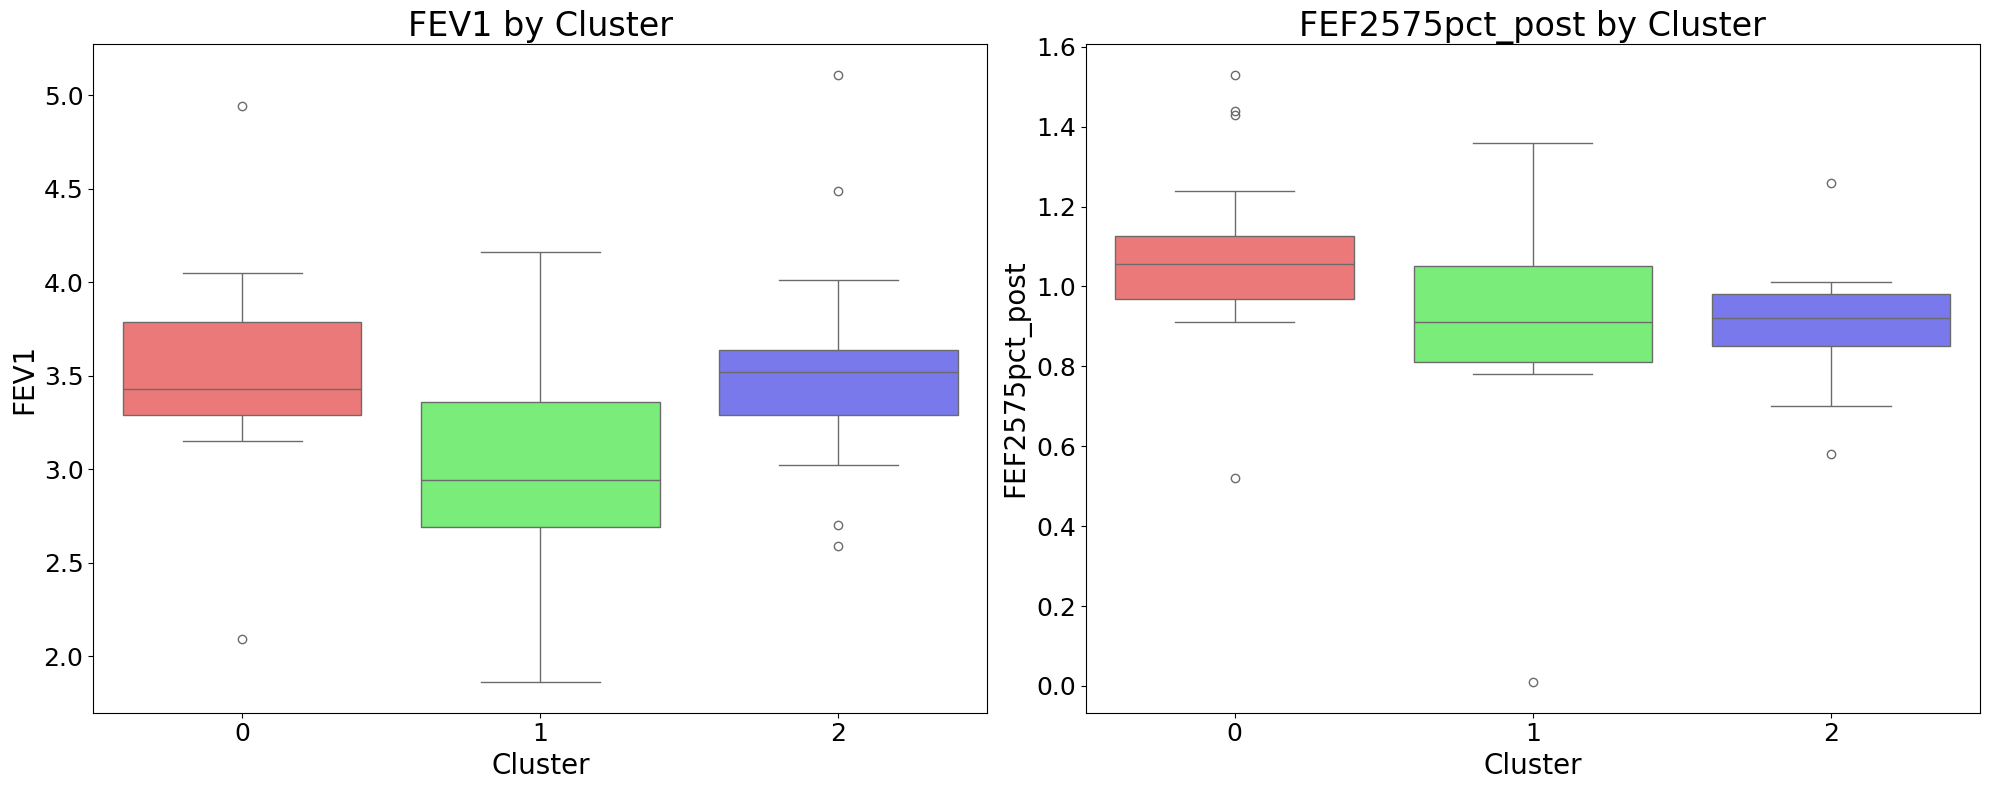

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Font size variables
TITLE_FS = 24
LABEL_FS = 20
TICK_FS = 18

# Lighter colors as RGBA tuples (R,G,B,A) with values 0–1
box_colors = {
    0: (1.0, 0.4, 0.4, 0.6),  # light red
    1: (0.4, 1.0, 0.4, 0.6),  # light green
    2: (0.4, 0.4, 1.0, 0.6)   # light blue
}
fig, axes = plt.subplots(1, 2, figsize=(20,8))

# FEV1 boxplot
sns.boxplot(
    x="cluster", y="FEV1", data=df_pe_cluster,
    hue="cluster", palette=box_colors, legend=False, ax=axes[0]
)

axes[0].set_title("FEV1 by Cluster", fontsize=TITLE_FS)
axes[0].set_xlabel("Cluster", fontsize=LABEL_FS)
axes[0].set_ylabel("FEV1", fontsize=LABEL_FS)
axes[0].tick_params(axis='both', labelsize=TICK_FS)

# FEF2575 boxplot
sns.boxplot(
    x="cluster", y="FEF2575pct_post", data=df_pe_cluster,
    hue="cluster", palette=box_colors, legend=False, ax=axes[1]
)

axes[1].set_title("FEF2575pct_post by Cluster", fontsize=TITLE_FS)
axes[1].set_xlabel("Cluster", fontsize=LABEL_FS)
axes[1].set_ylabel("FEF2575pct_post", fontsize=LABEL_FS)
axes[1].tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()


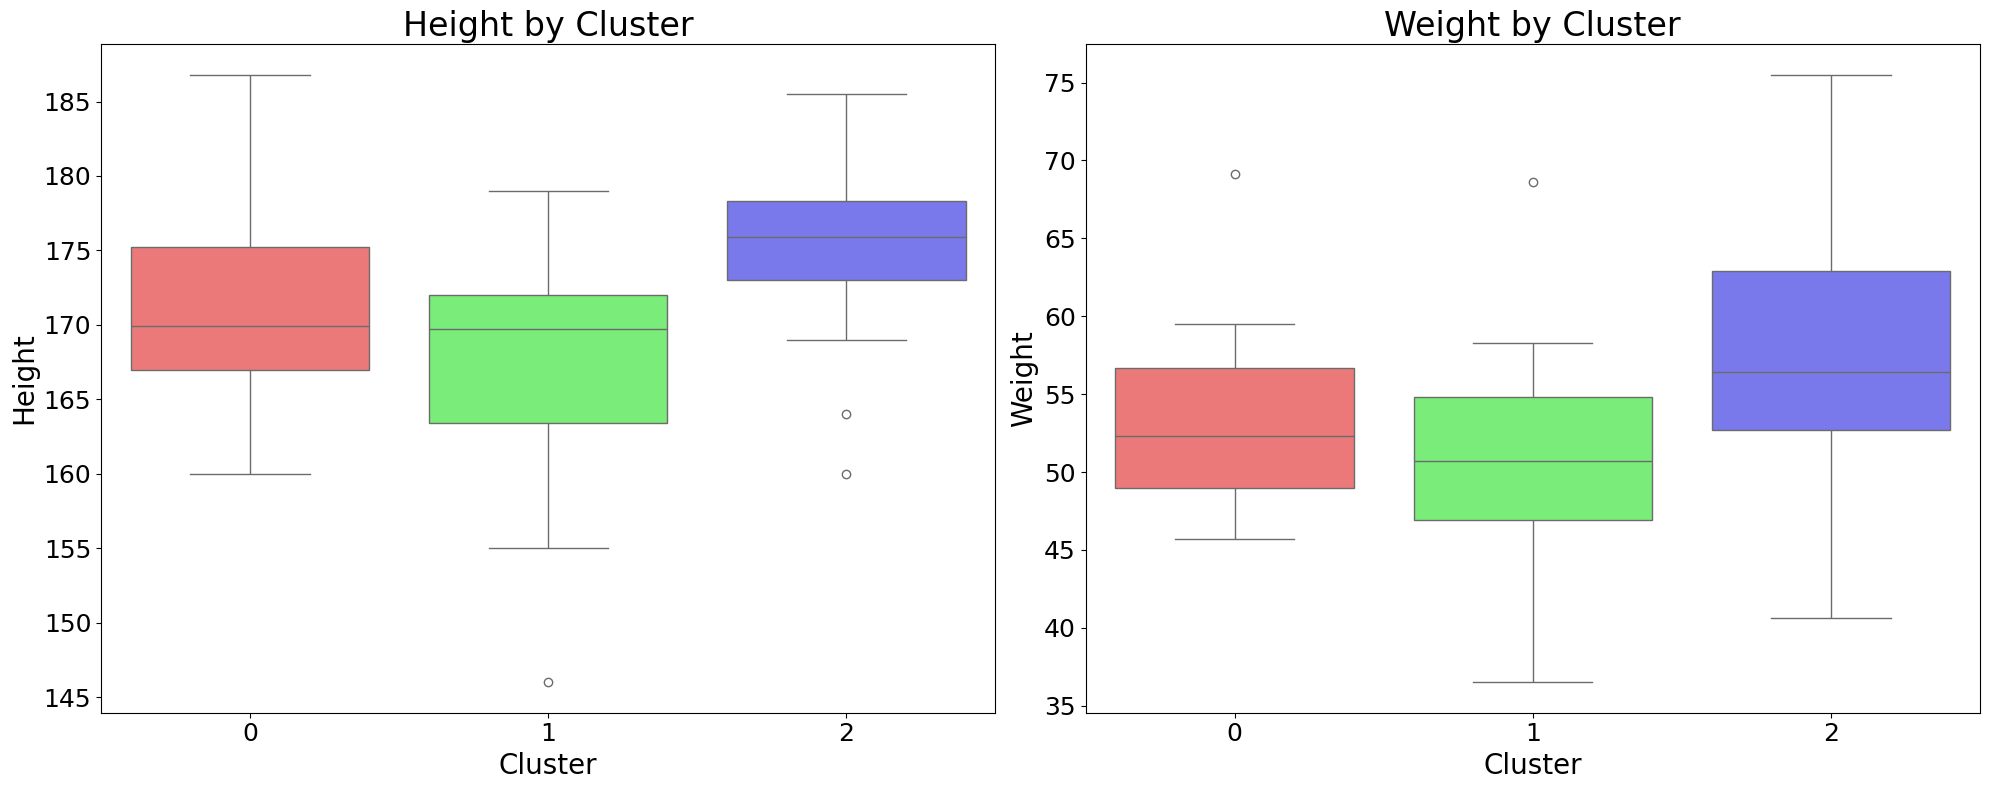

In [ ]:
# Font size variables
TITLE_FS = 24
LABEL_FS = 20
TICK_FS = 18

# Same lighter cluster colors as before
box_colors = {
    0: (1.0, 0.4, 0.4, 0.6),  # light red
    1: (0.4, 1.0, 0.4, 0.6),  # light green
    2: (0.4, 0.4, 1.0, 0.6)   # light blue
}

fig, axes = plt.subplots(1, 2, figsize=(20,8))

# Height boxplot
sns.boxplot(
    x="cluster", y="height", data=df_pe_cluster,
    hue="cluster", palette=box_colors, legend=False, ax=axes[0]
)
axes[0].set_title("Height by Cluster", fontsize=TITLE_FS)
axes[0].set_xlabel("Cluster", fontsize=LABEL_FS)
axes[0].set_ylabel("Height", fontsize=LABEL_FS)
axes[0].tick_params(axis='both', labelsize=TICK_FS)

# Weight boxplot
sns.boxplot(
    x="cluster", y="weight", data=df_pe_cluster,
    hue="cluster", palette=box_colors, legend=False, ax=axes[1]
)
axes[1].set_title("Weight by Cluster", fontsize=TITLE_FS)
axes[1].set_xlabel("Cluster", fontsize=LABEL_FS)
axes[1].set_ylabel("Weight", fontsize=LABEL_FS)
axes[1].tick_params(axis='both', labelsize=TICK_FS)

plt.tight_layout()
plt.show()